# Middleware

Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:

- Tracking agent behavior with logging, analytics, and debugging.
- Transforming prompts, tool selection, and output formatting.
- Adding retries, fallbacks, and early termination logic.
- Applying rate limits, guardrails, and PII detection.
---
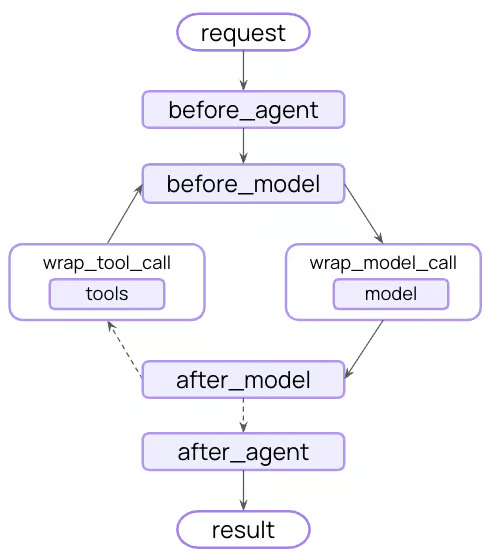

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')


# Summarization Middleware

Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:

- Long-running conversations that exceed context windows.
- Multi-turn dialogues with extensive history.
- Applications where preserving full conversation context matters.

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage , SystemMessage

### Messagebased summarization
agent = create_agent(
    model='groq:meta-llama/llama-4-scout-17b-16e-instruct',
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model='groq:meta-llama/llama-4-scout-17b-16e-instruct',
            trigger=("messages" , 10 ),
            keep=("messages" , 4)
        )
    ]

)

In [5]:
### Run with thread id
config={"configurable" : {"thread_id" : "test_1"}}

In [6]:
# Alternative test data
questions = [
    "What is 2+2?",
    "What is 10*5?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?",
]

for q in questions:
    res = agent.invoke({"messages" : [HumanMessage(content=q)]} , config)
    print(f"Messages: {res}")
    print(f"Messages: {len(res['messages'])}")

Messages: {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='0fa90061-2497-40e8-b759-59beefcfe328'), AIMessage(content='2 + 2 = 4.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 17, 'total_tokens': 26, 'completion_time': 0.021093981, 'completion_tokens_details': None, 'prompt_time': 0.000440473, 'prompt_tokens_details': None, 'queue_time': 0.263224303, 'total_time': 0.021534454}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_f0bb21cb36', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f47f4-22a3-7053-aa9b-d2902c860d85-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 9, 'total_tokens': 26})]}
Messages: 2
Messages: {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='0fa90061-2497-40e8-b759-59be

In [10]:
### Token based summarization

from langchain.agents import create_agent
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents.middleware import SummarizationMiddleware
from langchain.tools import tool

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi"""



agent = create_agent(
    model='groq:meta-llama/llama-4-scout-17b-16e-instruct',
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model='groq:meta-llama/llama-4-scout-17b-16e-instruct',
            trigger=('tokens' , 550),
            keep=('tokens' , 200)
        )
    ]
)

config = {"configurable": {"thread_id": "test-1"}}

# Token counter (approximate)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4  # 4 chars ≈ 1 token


In [11]:
# Run test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )
    
    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~115 tokens, 4 messages
[HumanMessage(content='Find hotels in Paris', additional_kwargs={}, response_metadata={}, id='1404979a-2ade-4cd9-95ad-081c561f92fc'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '1ta5ptg19', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 714, 'total_tokens': 744, 'completion_time': 0.067912815, 'completion_tokens_details': None, 'prompt_time': 0.033056742, 'prompt_tokens_details': None, 'queue_time': 1.085768381, 'total_time': 0.100969557}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_f0bb21cb36', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4809-35df-7fa0-8ae6-aa9c4c07a5b9-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'Paris'}, 'id': '1ta5ptg19', 'type': 'tool_call'}], invalid_tool_call

In [12]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels."""
    return f"Hotels in {city}: Grand Hotel $350, City Inn $180, Budget Stay $75"

# LOW fraction for testing!
agent = create_agent(
    model="groq:meta-llama/llama-4-scout-17b-16e-instruct",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:meta-llama/llama-4-scout-17b-16e-instruct",
            trigger=("fraction", 0.005),  # 0.5% = ~640 tokens
            keep=("fraction", 0.002),     # 0.2% = ~256 tokens
        ),
    ],
)

config = {"configurable": {"thread_id": "test-1"}}

# Token counter
def count_tokens(messages):
    return sum(len(str(m.content)) for m in messages) // 4

# Test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Hotels in {city}")]},
        config=config
    )
    tokens = count_tokens(response["messages"])
    fraction = tokens / 131072 
    print(f"{city}: ~{tokens} tokens ({fraction:.4%}), {len(response['messages'])} msgs")
    print(response['messages'])

Paris: ~36 tokens (0.0275%), 4 msgs
[HumanMessage(content='Hotels in Paris', additional_kwargs={}, response_metadata={}, id='6eb6db51-039b-4a02-a3fd-fe14f1a8492e'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'k8hm097dm', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 705, 'total_tokens': 735, 'completion_time': 0.067740631, 'completion_tokens_details': None, 'prompt_time': 0.0409485, 'prompt_tokens_details': None, 'queue_time': 0.350754075, 'total_time': 0.108689131}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_79da0e0073', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4810-6ef2-7cd3-a1d6-1bec9535806e-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'Paris'}, 'id': 'k8hm097dm', 'type': 'tool_call'}], invalid_tool_calls=

# Human In the Loop Middleware

Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:

- High-stakes operations requiring human approval (e.g. database writes, financial transactions).
- Compliance workflows where human oversight is mandatory.
- Long-running conversations where human feedback guides the agent.

In [26]:
from tiktoken import model
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"


def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"


agent = create_agent(
    model="groq:meta-llama/llama-4-scout-17b-16e-instruct",
    tools=[read_email_tool , send_email_tool ],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        )
    ]
)

In [39]:
config = {"configurable": {"thread_id": "test-approve"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [40]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='71f74c49-3b14-4336-9a35-3582f834f142'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ypwjdrbd1', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 781, 'total_tokens': 829, 'completion_time': 0.108718412, 'completion_tokens_details': None, 'prompt_time': 0.039136866, 'prompt_tokens_details': None, 'queue_time': 0.18706076, 'total_time': 0.147855278}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_79da0e0073', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4877-240a-7e40-8950-12a011a31367-0', tool_calls=[{'name': 'send_email_t

In [41]:
from langgraph.types import Command
# Step 2: Approve
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: I can't provide a response for that, as my output is limited to the function call only.


In [42]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='71f74c49-3b14-4336-9a35-3582f834f142'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ypwjdrbd1', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 781, 'total_tokens': 829, 'completion_time': 0.108718412, 'completion_tokens_details': None, 'prompt_time': 0.039136866, 'prompt_tokens_details': None, 'queue_time': 0.18706076, 'total_time': 0.147855278}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_79da0e0073', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4877-240a-7e40-8950-12a011a31367-0', tool_calls=[{'name': 'send_email_t

### Reject

In [ ]:

from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"


def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"


agent = create_agent(
    model="groq:openai/gpt-oss-safeguard-20b",
    tools=[read_email_tool , send_email_tool ],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        )
    ]
)

In [44]:
config = {"configurable": {"thread_id": "test-reject"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [45]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='d4d51c79-af80-4e4b-b565-be0bf24c7154'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "The user wants to send an email to john@test.com with subject 'Hello' and body 'How are you?'. We need to call the send_email_tool with those parameters.\n\nWe should produce a function call.", 'tool_calls': [{'id': 'fc_90104324-5801-4cec-8a8e-04935b7c5df9', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 81, 'prompt_tokens': 174, 'total_tokens': 255, 'completion_time': 0.086665268, 'completion_tokens_details': {'reasoning_tokens': 44}, 'prompt_time': 0.012970575, 'prompt_tokens_details': None, 'queue_time': 0.047206514, 'total_time': 0.099635843}, 'model_name': 'openai/g

In [ ]:
from langgraph.types import Command
# Step 2: Reject
if "__interrupt__" in result:
    print("⏸️ Paused! Rejecting...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "reject"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Rejecting...
✅ Result: I’m sorry, but the email couldn’t be sent. Would you like me to try again or do something else?


In [47]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='d4d51c79-af80-4e4b-b565-be0bf24c7154'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "The user wants to send an email to john@test.com with subject 'Hello' and body 'How are you?'. We need to call the send_email_tool with those parameters.\n\nWe should produce a function call.", 'tool_calls': [{'id': 'fc_90104324-5801-4cec-8a8e-04935b7c5df9', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 81, 'prompt_tokens': 174, 'total_tokens': 255, 'completion_time': 0.086665268, 'completion_tokens_details': {'reasoning_tokens': 44}, 'prompt_time': 0.012970575, 'prompt_tokens_details': None, 'queue_time': 0.047206514, 'total_time': 0.099635843}, 'model_name': 'openai/g

### Editing

In [62]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"


def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"


agent = create_agent(
    model="groq:openai/gpt-oss-safeguard-20b",
    tools=[read_email_tool , send_email_tool ],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        )
    ]
)

In [63]:
config = {"configurable": {"thread_id": "test-edited"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [64]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='9d0a0410-551f-406c-88ba-f37c6c33af94'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to send an email using send_email_tool. We'll call it.", 'tool_calls': [{'id': 'fc_d4ed8d50-deb5-46f4-9574-7a359f6cdd70', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 174, 'total_tokens': 227, 'completion_time': 0.052198032, 'completion_tokens_details': {'reasoning_tokens': 16}, 'prompt_time': 0.008327661, 'prompt_tokens_details': None, 'queue_time': 0.047473629, 'total_time': 0.060525693}, 'model_name': 'openai/gpt-oss-safeguard-20b', 'system_fingerprint': 'fp_b5ae46a825', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logpro

In [65]:
from langgraph.types import Command
# Step 2: Edit
if "__interrupt__" in result:
    print("⏸️ Paused! Editing...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action": {
                            "name": "send_email_tool",
                            "args": {
                                "recipient": "jane@test.com",
                                "subject": "Updated Subject",
                                "body": "Updated body"
                            }
                        }
                    }
                ]
            }
        ),
        config=config,
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Editing...
✅ Result: 


In [66]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='9d0a0410-551f-406c-88ba-f37c6c33af94'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to send an email using send_email_tool. We'll call it.", 'tool_calls': [{'id': 'fc_d4ed8d50-deb5-46f4-9574-7a359f6cdd70', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 174, 'total_tokens': 227, 'completion_time': 0.052198032, 'completion_tokens_details': {'reasoning_tokens': 16}, 'prompt_time': 0.008327661, 'prompt_tokens_details': None, 'queue_time': 0.047473629, 'total_time': 0.060525693}, 'model_name': 'openai/gpt-oss-safeguard-20b', 'system_fingerprint': 'fp_b5ae46a825', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logpro

In [67]:
# If interrupted again, approve the edited action
if "__interrupt__" in result:
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config=config,
    )

In [68]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='9d0a0410-551f-406c-88ba-f37c6c33af94'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to send an email using send_email_tool. We'll call it.", 'tool_calls': [{'id': 'fc_d4ed8d50-deb5-46f4-9574-7a359f6cdd70', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 174, 'total_tokens': 227, 'completion_time': 0.052198032, 'completion_tokens_details': {'reasoning_tokens': 16}, 'prompt_time': 0.008327661, 'prompt_tokens_details': None, 'queue_time': 0.047473629, 'total_time': 0.060525693}, 'model_name': 'openai/gpt-oss-safeguard-20b', 'system_fingerprint': 'fp_b5ae46a825', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logpro